In [143]:
# import pandas as pd
# import numpy as np
# print("hello world")
# data=pd.read_csv("Lite Narrators data.csv")
# df=pd.DataFrame(data)
# df.head()
# db = df[["name"]][50:100]


# # 3. Export to CSV
# db.to_csv('output.csv', index=False)

In [144]:
import io
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import sys


In [145]:


# 1. Raw CSV Data
csv_data = """
"Abu Hurayrah","-21","59"
"Aisha bint Abi Bakr","-8","58"
"Umar ibn al-Khattab","-40","23"
"Abdullah ibn Umar","-10","73"
"Abu Bakr al-Siddiq","-50","13"
"Malik ibn Anas","93","179"
"Al-Zuhri","50","124"
"Abdullah ibn Abbas","-3","68"
"Jabir ibn Abdullah","-16","78"
"Anas ibn Malik (Abu Hamza)","-10","93"
"","",""
"""

# 2. Parse the CSV rows
rows = []
for line in csv_data.strip().split("\n"):
    if line:
        parts = re.findall(r'"([^"]*)"', line)
        if len(parts) == 3:
            rows.append(parts)

df = pd.DataFrame(rows, columns=["Name", "Col1", "Col2"])


In [146]:
# Helper to grab integers
def extract_year(text):
    if not isinstance(text, str):  # Safety check for NaN or missing values
        return None
    nums = re.findall(r"-?\d+", text)
    return int(nums[0]) if nums else None  # Returns None if no number is found

Skipping row 10 due to missing numbers: , 


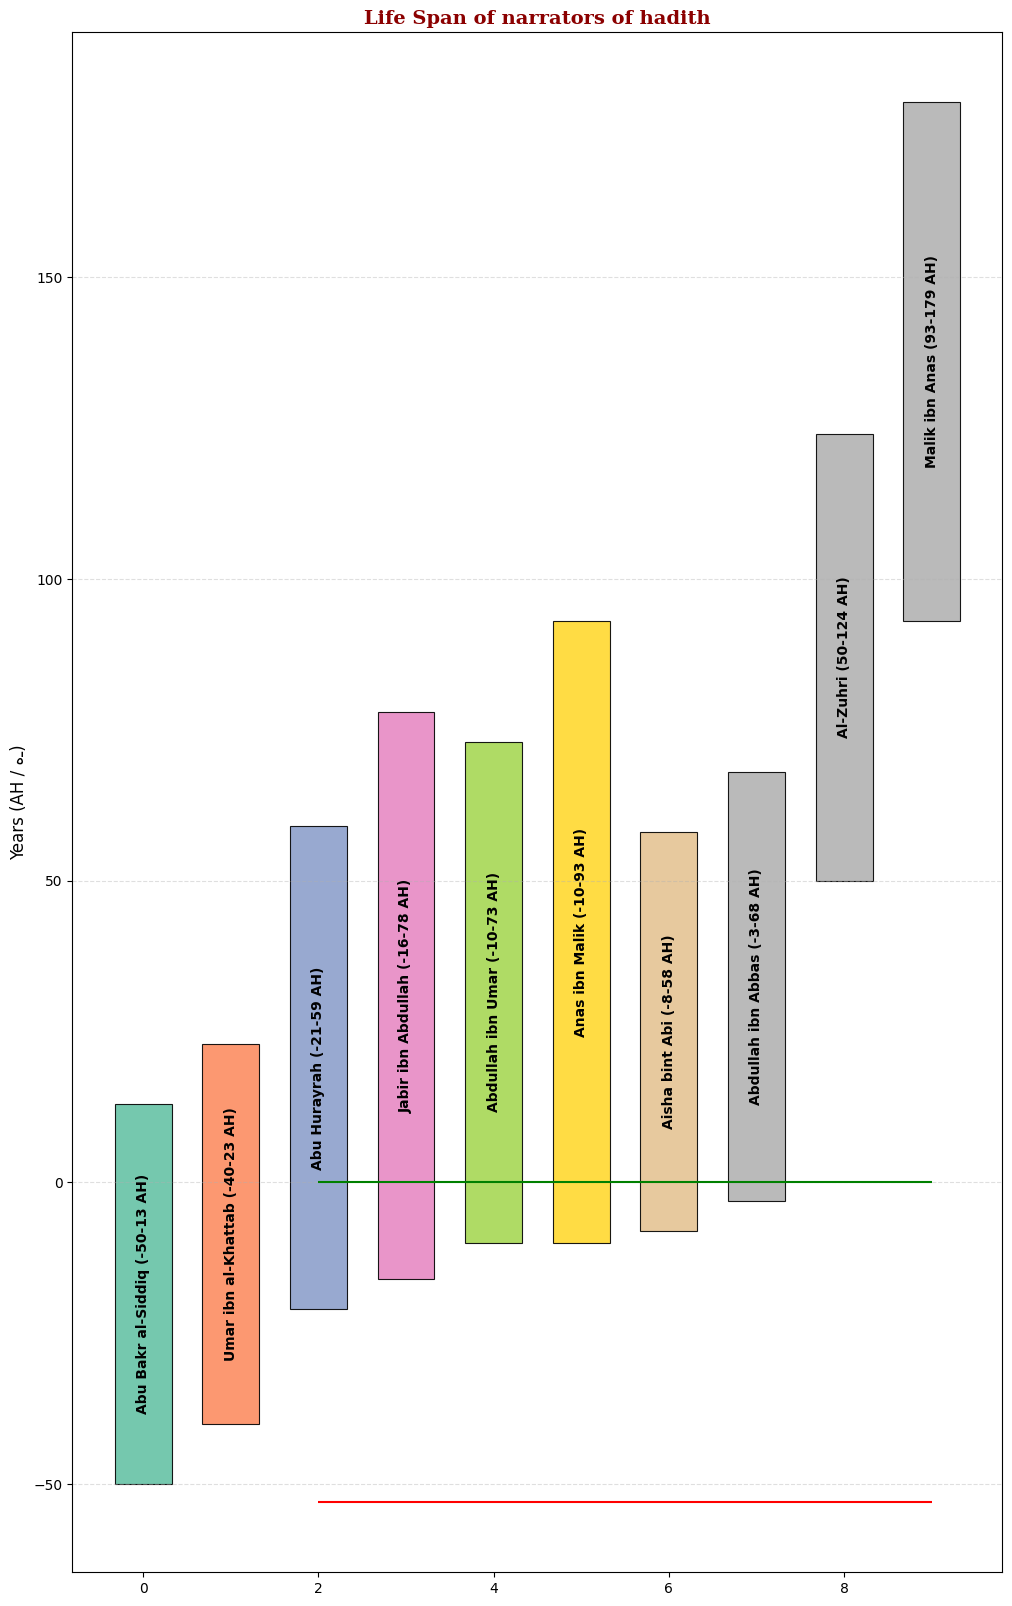

In [149]:
processed_rows = []
for idx, row in df.iterrows():
    n1 = extract_year(row["Col1"])
    n2 = extract_year(row["Col2"])
    if n1 is None or n2 is None:
        print(
            f"Skipping row {idx} due to missing numbers: {row['Col1']}, {row['Col2']}"
        )
        continue
    birth = min(n1, n2)
    death = max(n1, n2)
    processed_rows.append(
        {"Full Name": row["Name"], "Birth": birth, "Death": death}
    )

# Sort chronologically by birth date
pdf_sorted = pd.DataFrame(processed_rows).sort_values(by="Birth").reset_index(drop=True)

# 4. Plot Setup
fig, ax = plt.subplots(figsize=(12, 20))

# Define slot properties
slot_width = 0.65  # Adjust this to make the bars/slots wider or narrower
colors = plt.cm.Set2(
    np.arange(len(pdf_sorted))
)  # Distinct pastels for each slot

# Draw the block slots (height = lifespan duration)
ax.bar(
    pdf_sorted.index,
    pdf_sorted["Death"] - pdf_sorted["Birth"],
    bottom=pdf_sorted["Birth"],
    width=slot_width,
    color=colors,
    edgecolor="black",
    linewidth=0.8,
    alpha=0.9,
)

# 5. Placing Text Labels INSIDE the Slots

for i, row in pdf_sorted.iterrows():
    # Find the middle point of their lifespan to center the text
    mid_y = (row['Birth'] + row['Death']) / 2
    
    # Grab the first 3 words of the name so it isn't excessively long
    short_name = " ".join(row['Full Name'].split()[:3])
    
    # Construct the label string
    label_text = f"{short_name} ({row['Birth']}-{row['Death']} AH)"
    
    # Add text inside the bar rotated 90 degrees
    ax.text(
        i, 
        mid_y, 
        label_text, 
        ha='center', 
        va='center', 
        rotation=90,          # <-- This rotates the text vertically
        color='black', 
        fontweight='bold', 
        fontsize=10
    )
font = {'family': 'serif',
        'color':  'darkred',
        'weight': 'normal',
        'size': 20,
        }
# Formatting Layout
ax.set_ylabel("Years (AH / هـ)", fontsize=12)
ax.set_title(
    "Life Span of narrators of hadith",
    fontsize=14,
    fontweight="bold",fontdict=font,
)
# ax.set_xticks(pdf_sorted.index)
# ax.set_xticks([f"{row['Name']}" for i,row in pdf_sorted.iterrows()])

# Padding values slightly past limits to keep things breathable
ax.set_ylim(pdf_sorted["Birth"].min() - 25, pdf_sorted["Death"].max() + 25,auto=True)
ax.grid(visible=True,which="both",axis="y", linestyle="--", alpha=0.4,linewidth=0.8)
# grid(visible=None, which='major', axis='both',

# Hijra
plt.hlines(y=0, xmin=2, xmax=9, colors='green')
plt.hlines(y=-53, xmin=2, xmax=9, colors='red')
# plt.plot(x1, y1, x2, y2, marker = 'o')
# plt.tight_layout()
fig.savefig('test2png.svg', dpi=100)
plt.show()
